# 01 - EDA

This notebook examines the raw WESAD wrist signals.

## Notebook Goal

The goal is to answer these questions:

- How many subjects are available?
- What is inside each raw pickle file?
- Which wrist signals are present?
- How long are the recordings?
- Which labels appear in the raw data?
- Are the target labels balanced enough for the project task?

In [1]:
%load_ext autoreload
%autoreload 2

# Add the project root so the notebook can import from src/.
import sys
import warnings
sys.path.append("..")

# Standard analysis stack for tables and plots.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Hide the NumPy warning triggered by the WESAD pickle format.
warnings.filterwarnings("ignore", message="dtype\(\): align should be passed")

from src.loader import list_subjects, load_subject, load_subject_pickle

<>:16: SyntaxWarning: invalid escape sequence '\('
<>:16: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_182938/1306064608.py:16: SyntaxWarning: invalid escape sequence '\('
  warnings.filterwarnings("ignore", message="dtype\(\): align should be passed")


In [2]:
# Sampling rates from the dataset documentation.
SIGNAL_HZ = {
    "ACC": 32,
    "BVP": 64,
    "EDA": 4,
    "TEMP": 4,
}

LABEL_HZ = 700
TARGET_LABELS = [1, 2, 3]
LABEL_NAME_MAP = {
    0: "label_0",
    1: "baseline",
    2: "stress",
    3: "amusement",
    4: "meditation",
    5: "label_5",
    6: "label_6",
    7: "label_7",
}

## 1. Subjects Available

In [3]:
# List all subjects found in the local raw dataset folder.
subject_ids = list_subjects()
print(f"Found {len(subject_ids)} subjects")
subject_ids

Found 15 subjects


['S2',
 'S3',
 'S4',
 'S5',
 'S6',
 'S7',
 'S8',
 'S9',
 'S10',
 'S11',
 'S13',
 'S14',
 'S15',
 'S16',
 'S17']

**comment:** The notebook found 15 subjects, from `S2` to `S17`, with some missing IDs.

## 2. Raw Pickle Structure

In [4]:
# Inspect one subject to understand the raw file structure.
subject_id = "S2"
raw_subject = load_subject_pickle(subject_id)

print("Top-level keys:", sorted(raw_subject.keys()))
print("Signal groups:", sorted(raw_subject["signal"].keys()))
print("Wrist signals:", sorted(raw_subject["signal"]["wrist"].keys()))

Top-level keys: ['label', 'signal', 'subject']
Signal groups: ['chest', 'wrist']
Wrist signals: ['ACC', 'BVP', 'EDA', 'TEMP']


In [5]:
# Build a compact overview for one subject.
subject = load_subject(subject_id)

single_subject_overview = pd.DataFrame(
    [
        {
            "signal": signal_name,
            "shape": values.shape,
            "channels": values.shape[1] if values.ndim > 1 else 1,
            "sampling_rate_hz": SIGNAL_HZ[signal_name],
            "duration_min": values.shape[0] / SIGNAL_HZ[signal_name] / 60,
        }
        for signal_name, values in subject.wrist_signals.items()
    ]
)

display(single_subject_overview)
print("Label shape:", subject.labels.shape)
print("Label duration (min):", round(subject.labels.shape[0] / LABEL_HZ / 60, 2))

,signal,shape,channels,sampling_rate_hz,duration_min
0,ACC,"(194528, 3)",3,32,101.316667
1,BVP,"(389056, 1)",1,64,101.316667
2,EDA,"(24316, 1)",1,4,101.316667
3,TEMP,"(24316, 1)",1,4,101.316667


Label shape: (4255300,)
Label duration (min): 101.32


**comment:** Each raw file contains `subject`, `signal`, and `label`. Inside `signal`, there are `chest` and `wrist`. The wrist signals are `ACC`, `BVP`, `EDA`, and `TEMP`.

## 3. Build Reusable Summary Tables

In [6]:
# Load each subject only once so the rest of the notebook stays efficient.
subjects_data = {subject_id: load_subject(subject_id) for subject_id in subject_ids}

# Prepare summary rows for signals, labels, and quality checks.
signal_rows = []
label_rows = []
quality_rows = []

for subject_id, subject in subjects_data.items():
    labels = subject.labels.astype(int).ravel()

    quality_row = {
        "subject_id": subject_id,
        "label_samples": subject.labels.shape[0],
        "label_duration_min": subject.labels.shape[0] / LABEL_HZ / 60,
        "label_nan_count": int(np.isnan(subject.labels).sum()),
    }

    for signal_name, values in subject.wrist_signals.items():
        signal_rows.append(
            {
                "subject_id": subject_id,
                "signal": signal_name,
                "samples": values.shape[0],
                "channels": values.shape[1] if values.ndim > 1 else 1,
                "sampling_rate_hz": SIGNAL_HZ[signal_name],
                "duration_min": values.shape[0] / SIGNAL_HZ[signal_name] / 60,
                "nan_count": int(np.isnan(values).sum()),
            }
        )

        quality_row[f"{signal_name}_duration_min"] = values.shape[0] / SIGNAL_HZ[signal_name] / 60
        quality_row[f"{signal_name}_nan_count"] = int(np.isnan(values).sum())

    value_counts = pd.Series(labels).value_counts().sort_index()
    total = int(value_counts.sum())
    for label_value, count in value_counts.items():
        label_rows.append(
            {
                "subject_id": subject_id,
                "label": int(label_value),
                "label_name": LABEL_NAME_MAP.get(int(label_value), f"label_{int(label_value)}"),
                "count": int(count),
                "percentage": 100 * count / total,
            }
        )

    quality_rows.append(quality_row)

signal_summary = pd.DataFrame(signal_rows)
label_summary = pd.DataFrame(label_rows)
quality_summary = pd.DataFrame(quality_rows)

print("signal_summary shape:", signal_summary.shape)
print("label_summary shape:", label_summary.shape)
print("quality_summary shape:", quality_summary.shape)

signal_summary shape: (60, 7)
label_summary shape: (119, 5)
quality_summary shape: (15, 12)


**comment:** Three summary tables were created: `signal_summary` with shape `(60, 7)`, `label_summary` with shape `(119, 5)`, and `quality_summary` with shape `(15, 12)`.

## 4. Recording Duration and Signal Shape

In [7]:
# Summarize duration and signal shape across all subjects.
display(
    signal_summary.groupby("signal")[["samples", "channels", "duration_min"]].agg(["min", "max", "mean"])
)

subject_duration = quality_summary[["subject_id", "label_duration_min"]].rename(
    columns={"label_duration_min": "recording_duration_min"}
)
display(subject_duration)

samples                   channels          duration_min               
           min     max      mean      min max mean          min     max   mean
signal                                                                        
ACC     167136  226272  185318.4        3   3  3.0        87.05  117.85  96.52
BVP     334272  452544  370636.8        1   1  1.0        87.05  117.85  96.52
EDA      20892   28284   23164.8        1   1  1.0        87.05  117.85  96.52
TEMP     20892   28284   23164.8        1   1  1.0        87.05  117.85  96.52

,subject_id,recording_duration_min
0,S2,101.316667
1,S3,108.216667
2,S4,107.050000
3,S5,104.300000
4,S6,117.850000
5,S7,87.300000
6,S8,91.100000
7,S9,87.050000
8,S10,91.600000
9,S11,87.216667


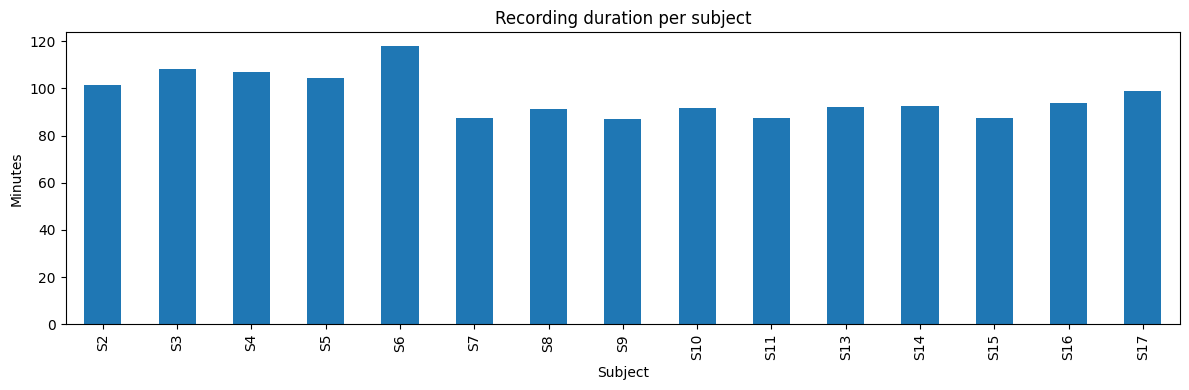

In [8]:
# Plot the recording duration for each subject.
ax = subject_duration.plot(
    x="subject_id",
    y="recording_duration_min",
    kind="bar",
    figsize=(12, 4),
    legend=False,
)
ax.set_title("Recording duration per subject")
ax.set_xlabel("Subject")
ax.set_ylabel("Minutes")
plt.tight_layout()

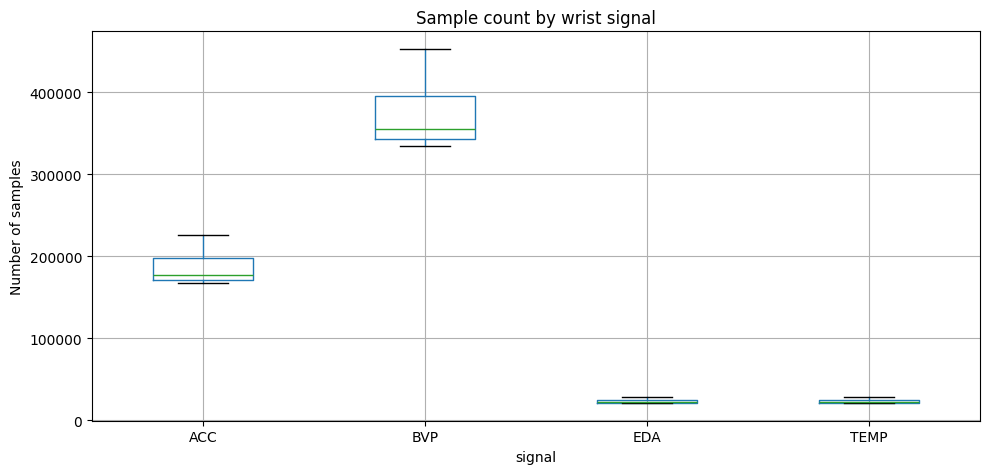

In [9]:
# Compare sample counts across wrist modalities.
fig, ax = plt.subplots(figsize=(10, 5))
signal_summary.boxplot(column="samples", by="signal", ax=ax)
ax.set_title("Sample count by wrist signal")
ax.set_ylabel("Number of samples")
plt.suptitle("")
plt.tight_layout()

**comment:** Recording duration changes across subjects. The minimum is about 87.05 minutes, the maximum is about 117.85 minutes, and the mean is about 96.52 minutes.

## 5. Basic Quality Checks

In [10]:
# Check duration alignment and missing values.
quality_checks = pd.DataFrame(
    {
        "subject_id": quality_summary["subject_id"],
        "duration_match": (
            quality_summary[["label_duration_min", "ACC_duration_min", "BVP_duration_min", "EDA_duration_min", "TEMP_duration_min"]]
            .round(6)
            .nunique(axis=1)
            == 1
        ),
        "total_nan_count": quality_summary[
            ["label_nan_count", "ACC_nan_count", "BVP_nan_count", "EDA_nan_count", "TEMP_nan_count"]
        ].sum(axis=1),
    }
)

display(quality_checks)
print("All durations aligned:", quality_checks["duration_match"].all())
print("Any NaNs found:", bool((quality_checks["total_nan_count"] > 0).any()))

,subject_id,duration_match,total_nan_count
0,S2,True,0
1,S3,True,0
2,S4,True,0
3,S5,True,0
4,S6,True,0
5,S7,True,0
6,S8,True,0
7,S9,True,0
8,S10,True,0
9,S11,True,0


All durations aligned: True
Any NaNs found: False


**comment:** For all subjects, `duration_match` is `True` and `total_nan_count` is `0`. The printed output also says `All durations aligned: True` and `Any NaNs found: False`.

## 6. Full Label Distribution

In [11]:
# Aggregate label counts over the full dataset.
overall_label_distribution = (
    label_summary.groupby(["label", "label_name"], as_index=False)["count"].sum()
    .sort_values("label")
)
overall_label_distribution["percentage"] = (
    100 * overall_label_distribution["count"] / overall_label_distribution["count"].sum()
)
display(overall_label_distribution)

,label,label_name,count,percentage
0,0,label_0,27654897,45.479343
1,1,baseline,12327702,20.273291
2,2,stress,6976201,11.472581
3,3,amusement,3902501,6.417785
4,4,meditation,8264199,13.590734
5,5,label_5,552300,0.908275
6,6,label_6,552998,0.909423
7,7,label_7,576802,0.948569


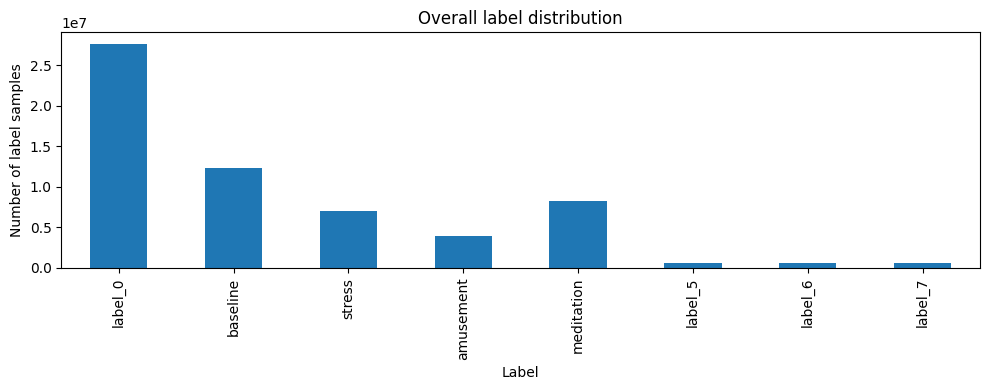

In [12]:
# Visualize all raw labels, including non-target labels.
ax = overall_label_distribution.plot(
    x="label_name",
    y="count",
    kind="bar",
    figsize=(10, 4),
    legend=False,
)
ax.set_title("Overall label distribution")
ax.set_xlabel("Label")
ax.set_ylabel("Number of label samples")
plt.tight_layout()

**comment:** The raw label output shows eight labels: `0`, `1`, `2`, `3`, `4`, `5`, `6`, and `7`. The largest one is `label_0`, with about 45.48% of the label samples.

## 7. Target Labels for the Final Task

In [13]:
# Focus only on the three labels used in the project task.
target_label_counts = (
    label_summary[label_summary["label"].isin(TARGET_LABELS)]
    .pivot(index="subject_id", columns="label_name", values="count")
    .fillna(0)
)

target_label_percentages = target_label_counts.div(target_label_counts.sum(axis=1), axis=0) * 100

display(target_label_counts)
display(target_label_percentages.round(2))

label_name,amusement,baseline,stress
subject_id,,,
S10,260400,826000,507500
S11,257600,826000,476000
S13,267400,826001,464800
S14,260401,826000,472500
S15,260400,822500,480200
S16,257600,826000,471101
S17,260400,826700,506100
S2,253400,800800,430500
S3,262500,798000,448000


label_name,amusement,baseline,stress
subject_id,,,
S10,16.34,51.82,31.84
S11,16.52,52.96,30.52
S13,17.16,53.01,29.83
S14,16.70,52.99,30.31
S15,16.66,52.62,30.72
S16,16.57,53.13,30.30
S17,16.34,51.89,31.77
S2,17.07,53.94,29.00
S3,17.40,52.90,29.70


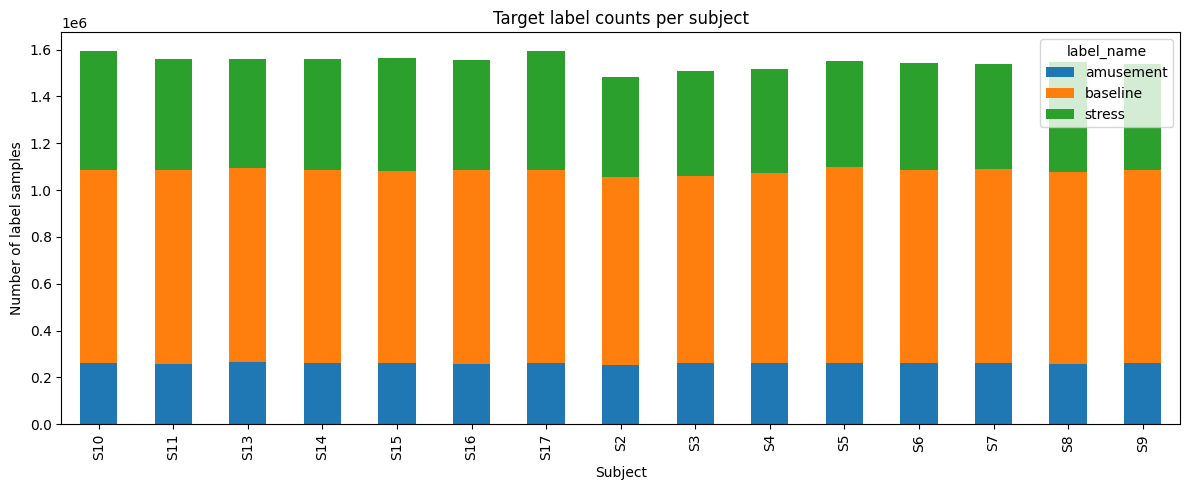

In [14]:
# Show target label counts for each subject.
ax = target_label_counts.plot(kind="bar", stacked=True, figsize=(12, 5))
ax.set_title("Target label counts per subject")
ax.set_xlabel("Subject")
ax.set_ylabel("Number of label samples")
plt.tight_layout()

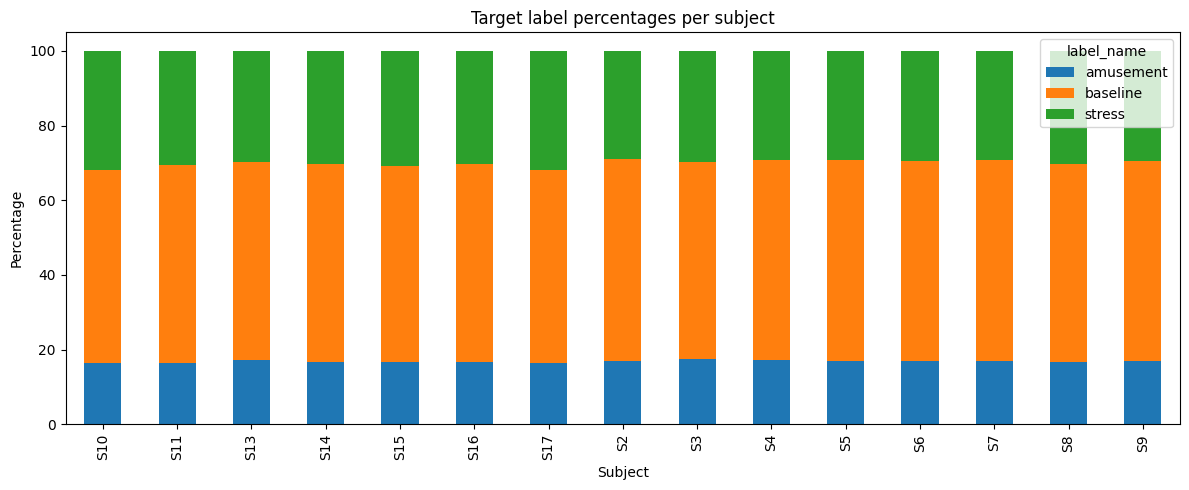

In [15]:
# Show target label proportions for each subject.
ax = target_label_percentages.plot(kind="bar", stacked=True, figsize=(12, 5))
ax.set_title("Target label percentages per subject")
ax.set_xlabel("Subject")
ax.set_ylabel("Percentage")
plt.tight_layout()

**comment:** In the target label tables, `baseline` is the largest class for every subject. The percentages are around 52-54% for `baseline`, 29-32% for `stress`, and 16-17% for `amusement`.

## 8. Subject Variability

- `baseline` is the largest class in every subject.
- `stress` is around 29-32%.
- `amusement` is around 16-17%.

## 9. Non-Target Labels

In [16]:
# Keep the non-target labels visible so preprocessing decisions stay explicit.
non_target_distribution = overall_label_distribution[
    ~overall_label_distribution["label"].isin(TARGET_LABELS)
]
display(non_target_distribution)

,label,label_name,count,percentage
0,0,label_0,27654897,45.479343
4,4,meditation,8264199,13.590734
5,5,label_5,552300,0.908275
6,6,label_6,552998,0.909423
7,7,label_7,576802,0.948569


**comment:** The non-target label table shows that `label_0` and `meditation` are much larger than `label_5`, `label_6`, and `label_7`.

## 10. Short Raw Signal Segments

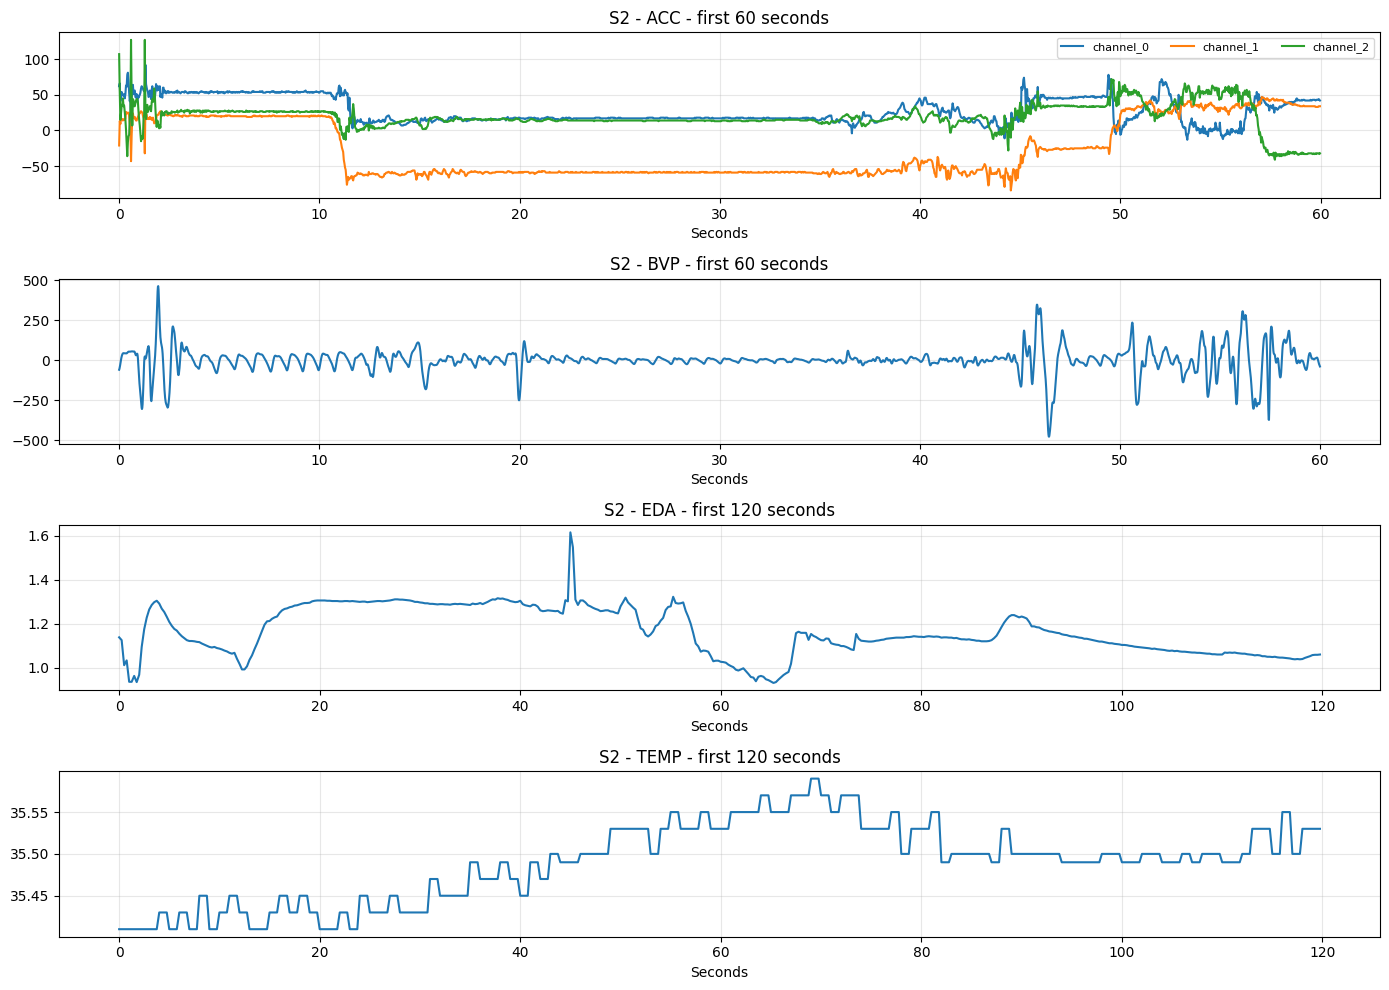

In [17]:
# Plot short segments to inspect scale, smoothness, and channel structure.
subject_id = "S2"
subject = subjects_data[subject_id]

plot_order = ["ACC", "BVP", "EDA", "TEMP"]
seconds_to_plot = {
    "ACC": 60,
    "BVP": 60,
    "EDA": 120,
    "TEMP": 120,
}

fig, axes = plt.subplots(len(plot_order), 1, figsize=(14, 10))

for ax, signal_name in zip(axes, plot_order):
    values = subject.wrist_signals[signal_name]
    hz = SIGNAL_HZ[signal_name]
    limit = min(int(seconds_to_plot[signal_name] * hz), len(values))
    segment = values[:limit]
    time_axis = np.arange(limit) / hz

    if segment.ndim == 2 and segment.shape[1] > 1:
        for channel_index in range(segment.shape[1]):
            ax.plot(time_axis, segment[:, channel_index], label=f"channel_{channel_index}")
        ax.legend(loc="upper right", ncol=3, fontsize=8)
    else:
        ax.plot(time_axis, segment.reshape(-1))

    ax.set_title(f"{subject_id} - {signal_name} - first {seconds_to_plot[signal_name]} seconds")
    ax.set_xlabel("Seconds")
    ax.grid(alpha=0.3)

plt.tight_layout()

**comment:** The plots show different scales and patterns across the four wrist signals. In the single-subject table, `ACC` has 3 channels, while `BVP`, `EDA`, and `TEMP` have 1 channel.

## 11. Findings from the Outputs

- The notebook found 15 subjects.
- The wrist signals are `ACC`, `BVP`, `EDA`, and `TEMP`.
- For `S2`, the signal duration and the label duration are both about 101.32 minutes.
- Recording duration ranges from about 87.05 to 117.85 minutes.
- All durations are aligned and no NaN values were found.
- The raw dataset contains eight labels.
- In the target label tables, `baseline` is the largest class for every subject.

## 12. Final Comments

This notebook shows the raw data structure, duration, quality checks, and label distribution.

## Final EDA Summary

- The local dataset contains 15 subjects.
- The wrist signals are `ACC`, `BVP`, `EDA`, and `TEMP`.
- For `S2`, the signals and labels have the same duration of about 101.32 minutes.
- Across subjects, recording duration ranges from about 87.05 to 117.85 minutes.
- No missing values were found in the raw wrist signals or labels.
- The raw label output contains eight labels.
- In the target label tables, `baseline` is the largest class for every subject.

These outputs describe the raw wrist data.